# 03 – Preprocessing & DataLoader
**Szerző:** Magda Ferenc (U5O0BB)  
**Projekt:** Gitár akkord felismerő szoftver gépi látással  
**Notebook célja:** PyTorch Dataset + DataLoader felépítése a `split_manifest.csv` alapján,
augmentációs pipeline és class weight számítás.

**Döntések:**
- Célméret: **224×224** (ResNet/EfficientNet szabvány)
- Normalizálás: **ImageNet** mean/std (transfer learning-hez)
- Augmentáció: RandomHorizontalFlip, ColorJitter, RandomRotation(±15°)
- Class weight: **igen** – alulreprezentált osztályok (G, No hand, E) súlyozása

---
*Tartalomjegyzék*
1. Könyvtárak és konfiguráció
2. Manifest betöltése & osztálykódok
3. Class weights számítása
4. Transforms pipeline (train / val / test)
5. `GuitarChordDataset` osztály
6. DataLoader setup
7. Sanity check – egy batch vizualizáció
8. Összefoglaló és következő lépések

<a id='1'></a>
## 1. Könyvtárak és konfiguráció

In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image

warnings.filterwarnings("ignore")

# ── Elérési utak ─────────────────────────────────────────────────────────────
NOTEBOOK_DIR  = Path(__file__).parent if "__file__" in dir() else Path.cwd()
PROJECT_ROOT  = NOTEBOOK_DIR.parent
DATA_ROOT     = PROJECT_ROOT / "data"
MANIFEST_PATH = DATA_ROOT / "split_manifest.csv"

NOTEBOOK_NAME = "03_preprocessing"
OUTPUT_DIR    = PROJECT_ROOT / "output" / NOTEBOOK_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Hiperparaméterek ──────────────────────────────────────────────────────────
IMG_SIZE    = 224          # px
BATCH_SIZE  = 16
NUM_WORKERS = 0            # lokális futtatáshoz; több CPU esetén növelhető
RANDOM_SEED = 42

# Runtime eszköz: CPU fallback, ha CUDA nem érhető el
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ImageNet normalizálás (pretrained modelleknél szabvány)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

for d in [DATA_ROOT, MANIFEST_PATH]:
    status = "OK" if d.exists() else "❌ NEM TALÁLHATÓ"
    print(f"{status}  {d}")

print(f"\nPyTorch verzió: {torch.__version__}")
print(f"CUDA elérhető:  {torch.cuda.is_available()}")
print(f"Eszköz:         {DEVICE}")


OK  /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/data
OK  /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/data/split_manifest.csv

PyTorch verzió: 2.6.0+cu124
CUDA elérhető:  True
Eszköz:         cuda


<a id='2'></a>
## 2. Manifest betöltése & osztálykódok

In [3]:
manifest = pd.read_csv(MANIFEST_PATH)

# Konzisztens, ábécé-sorrendű osztálycímkék → integer kódok
CLASSES    = sorted(manifest["class"].unique())
CLASS2IDX  = {c: i for i, c in enumerate(CLASSES)}
IDX2CLASS  = {i: c for c, i in CLASS2IDX.items()}
NUM_CLASSES = len(CLASSES)

manifest["label"] = manifest["class"].map(CLASS2IDX)

train_df = manifest[manifest["split"] == "train"].reset_index(drop=True)
val_df   = manifest[manifest["split"] == "val"].reset_index(drop=True)
test_df  = manifest[manifest["split"] == "test"].reset_index(drop=True)

print(f"Osztályok ({NUM_CLASSES} db): {CLASSES}")
print(f"\nSplit méretek – train: {len(train_df)} | val: {len(val_df)} | test: {len(test_df)}")
print(f"\nclass → idx leképzés:")
for c, i in CLASS2IDX.items():
    print(f"  {i}: {c}")


Osztályok (8 db): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'No hand']

Split méretek – train: 207 | val: 45 | test: 45

class → idx leképzés:
  0: A
  1: B
  2: C
  3: D
  4: E
  5: F
  6: G
  7: No hand


<a id='3'></a>
## 3. Class weights számítása

Az inverz frekvencia módszer: kisebb osztály → nagyobb súly.  
Ezeket átadjuk a `CrossEntropyLoss(weight=...)` paraméterének.

\[
w_c = \frac{N_{\text{train}}}{K \cdot n_c}
\]

ahol \(N_{\text{train}}\) a train képek száma, \(K\) az osztályok száma, \(n_c\) az adott osztály képeinek száma.

In [4]:
class_counts = train_df["class"].value_counts()

# Inverz frekvencia normálva
weights = {}
for cls in CLASSES:
    n_c = class_counts.get(cls, 1)
    weights[cls] = len(train_df) / (NUM_CLASSES * n_c)

# torch tensor – sorrendje CLASS2IDX alapján
class_weights = torch.tensor(
    [weights[c] for c in CLASSES],
    dtype=torch.float
)

print("Class weights (CrossEntropyLoss-hoz):")
for cls, w in zip(CLASSES, class_weights):
    n_c = class_counts.get(cls, 0)
    print(f"  {cls:10s}  n={n_c:>3}  weight={w:.4f}")

print(f"\ntorch.Tensor: {class_weights}")


Class weights (CrossEntropyLoss-hoz):
  A           n= 23  weight=1.1250
  B           n= 39  weight=0.6635
  C           n= 33  weight=0.7841
  D           n= 31  weight=0.8347
  E           n= 22  weight=1.1761
  F           n= 34  weight=0.7610
  G           n= 15  weight=1.7250
  No hand     n= 10  weight=2.5875

torch.Tensor: tensor([1.1250, 0.6635, 0.7841, 0.8347, 1.1761, 0.7610, 1.7250, 2.5875])


<a id='4'></a>
## 4. Transforms pipeline

| Lépés | Train | Val / Test |
|-------|-------|------------|
| Resize | 256×256 | 256×256 |
| Crop | RandomCrop(224) | CenterCrop(224) |
| HorizontalFlip | p=0.5 | – |
| ColorJitter | brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1 | – |
| Rotation | ±15° | – |
| ToTensor | ✓ | ✓ |
| Normalize | ImageNet | ImageNet |

**Megjegyzés:** A gitárakkord-képeken a vízszintes tükrözés zeneileg érvényes marad
(A-akkord tükörképe is A-akkord), ezért `p=0.5` megfelelő.

In [5]:
train_transforms = T.Compose([
    T.Resize(256),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    T.RandomRotation(degrees=15),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transforms = T.Compose([
    T.Resize(256),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Train transforms:")
print(train_transforms)
print("\nVal/Test transforms:")
print(val_test_transforms)


Train transforms:
Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    RandomCrop(size=(224, 224), padding=None)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.8, 1.2), hue=(-0.1, 0.1))
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Val/Test transforms:
Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


<a id='5'></a>
## 5. `GuitarChordDataset` osztály

A dataset közvetlenül a `split_manifest.csv` soraiból dolgozik –
nem kell semmiféle mappastruktúrára támaszkodni.

In [6]:
class GuitarChordDataset(Dataset):
    """
    Gitár akkord képek datasete a split_manifest.csv alapján.

    Paraméterek
    -----------
    df         : pd.DataFrame – manifest szűrt splitje
    transform  : torchvision transforms pipeline
    class2idx  : dict – osztálynév → integer label
    """

    def __init__(self, df: pd.DataFrame, transform=None, class2idx: dict = None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.class2idx = class2idx or CLASS2IDX

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")
        label = int(row["label"]) if "label" in row else self.class2idx[row["class"]]

        if self.transform:
            image = self.transform(image)

        return image, label

    def get_class_name(self, label_idx: int) -> str:
        return IDX2CLASS[label_idx]


# ── Példányosítás ─────────────────────────────────────────────────────────────
train_dataset = GuitarChordDataset(train_df, transform=train_transforms)
val_dataset   = GuitarChordDataset(val_df,   transform=val_test_transforms)
test_dataset  = GuitarChordDataset(test_df,  transform=val_test_transforms)

print(f"Train dataset mérete:  {len(train_dataset)}")
print(f"Val   dataset mérete:  {len(val_dataset)}")
print(f"Test  dataset mérete:  {len(test_dataset)}")

# Egyetlen elem ellenőrzése
img, lbl = train_dataset[0]
print(f"\nPélda elem – kép shape: {img.shape} | label: {lbl} ({IDX2CLASS[lbl]})")
print(f"Pixel értékek: min={img.min():.3f}, max={img.max():.3f}, mean={img.mean():.3f}")


Train dataset mérete:  207
Val   dataset mérete:  45
Test  dataset mérete:  45

Példa elem – kép shape: torch.Size([3, 224, 224]) | label: 0 (A)
Pixel értékek: min=-2.118, max=1.978, mean=-0.670


<a id='6'></a>
## 6. DataLoader setup

In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    drop_last=True,   # utolsó, hiányos batch eldobása
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print(f"Train loader – batch-ek száma: {len(train_loader)}")
print(f"Val   loader – batch-ek száma: {len(val_loader)}")
print(f"Test  loader – batch-ek száma: {len(test_loader)}")

# Egy batch próba
imgs, labels = next(iter(train_loader))
print(f"\nPróba batch shape: {imgs.shape}  |  labels: {labels.tolist()}")


Train loader – batch-ek száma: 12
Val   loader – batch-ek száma: 3
Test  loader – batch-ek száma: 3

Próba batch shape: torch.Size([16, 3, 224, 224])  |  labels: [3, 5, 3, 6, 2, 3, 5, 5, 4, 0, 2, 5, 0, 2, 5, 5]


<a id='7'></a>
## 7. Sanity check – egy batch vizualizáció

Denormalizált képek megjelenítése, hogy lássuk ténylegesen mit lát a modell
augmentáció után.

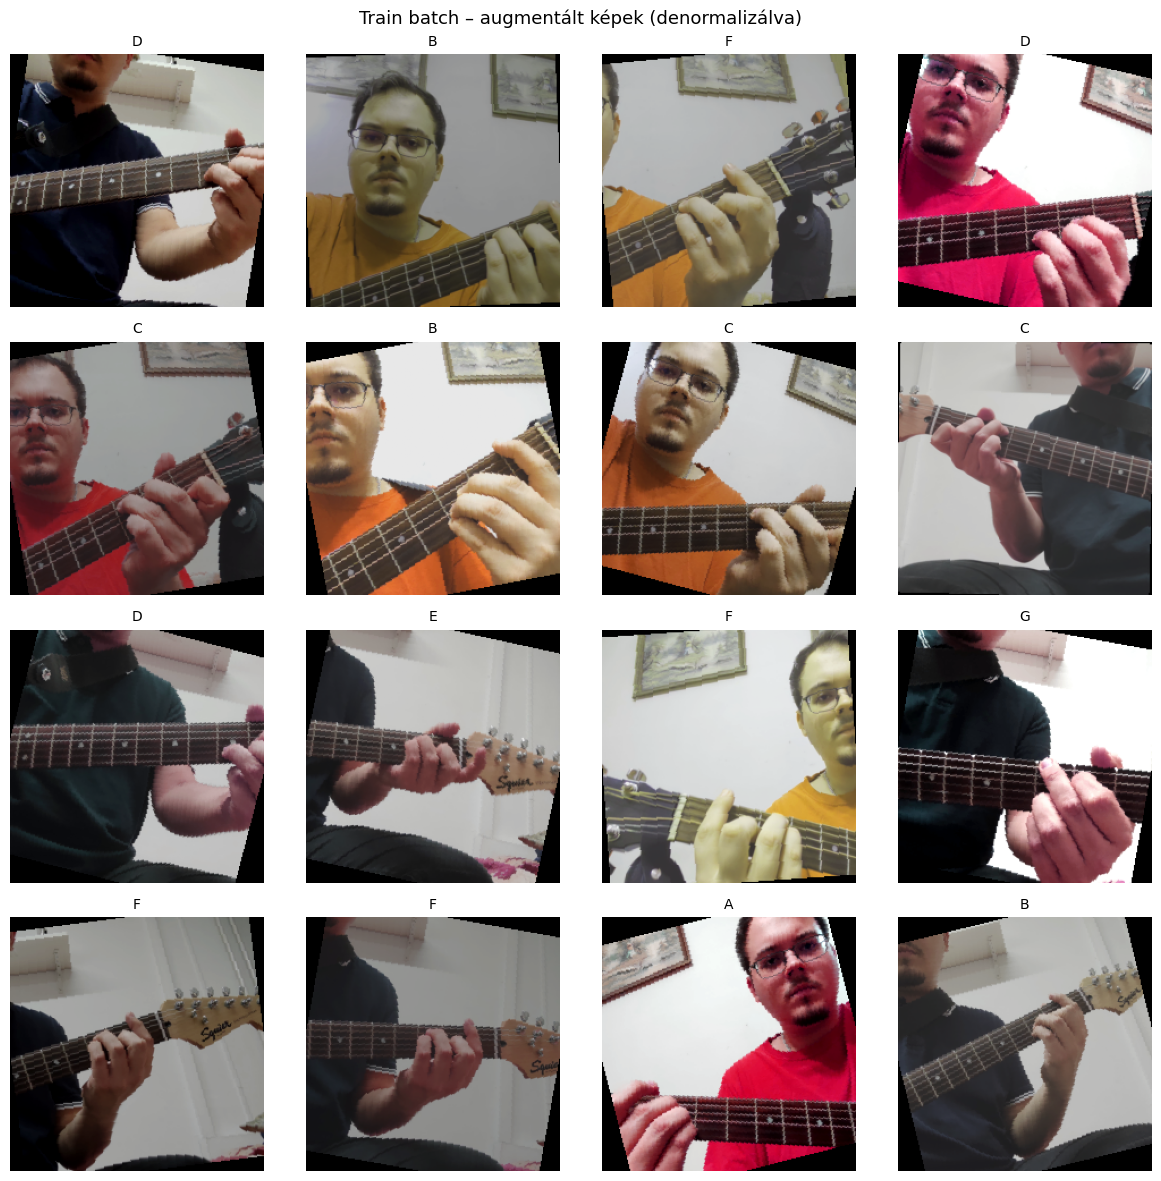

Ábra elmentve: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/output/03_preprocessing/train_batch_sanity.png


In [8]:
def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Visszaalakítja a normalizált tensort megjelenítésre."""
    t = tensor.clone()
    for c, (m, s) in enumerate(zip(mean, std)):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)

imgs, labels = next(iter(train_loader))

n_show = min(16, len(imgs))
cols   = 4
rows   = (n_show + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten()

for i in range(n_show):
    img = denormalize(imgs[i]).permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    axes[i].set_title(IDX2CLASS[labels[i].item()], fontsize=10)
    axes[i].axis("off")

for j in range(n_show, len(axes)):
    axes[j].axis("off")

plt.suptitle("Train batch – augmentált képek (denormalizálva)", fontsize=13)
plt.tight_layout()
save_path = OUTPUT_DIR / "train_batch_sanity.png"
plt.savefig(save_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Ábra elmentve: {save_path}")


<a id='8'></a>
## 8. Összefoglaló és következő lépések

### Mit értünk el?
- ✅ `GuitarChordDataset` – manifest-alapú, újrafelhasználható PyTorch Dataset
- ✅ Augmentációs pipeline (train) és clean pipeline (val/test)
- ✅ ImageNet normalizálás – pretrained modelleknél szükséges
- ✅ Class weights – alulreprezentált osztályok kompenzálása
- ✅ DataLoader-ek (train shuffle, val/test fix)
- ✅ Sanity check vizualizáció

### Használat a modell notebookban

```python
from pathlib import Path
import pandas as pd
from notebooks.preprocessing import GuitarChordDataset, CLASS2IDX, class_weights

# vagy egyszerűen importáld a változókat ebből a notebookból
# train_loader, val_loader, test_loader, class_weights, NUM_CLASSES készen vannak
```

### Következő lépések (`04_model.ipynb`)

| # | Lépés | Megjegyzés |
|---|-------|------------|
| 1 | Pretrained alap | EfficientNet-B0 vagy ResNet-18 választása |
| 2 | Fine-tuning stratégia | Frozen backbone → csak classifier; majd fokozatos felolvasztás |
| 3 | Loss | `CrossEntropyLoss(weight=class_weights)` |
| 4 | Optimizer | AdamW, lr=1e-3 (classifier), lr=1e-4 (backbone) |
| 5 | Scheduler | CosineAnnealingLR vagy ReduceLROnPlateau |
| 6 | Early stopping | patience=10, monitor: val_loss |